In [1]:
from IPython.core.pylabtools import figsize
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [10]:
x, y = load_breast_cancer(return_X_y=True)
Xtr, Xtst, ytr, ytst = train_test_split(x, y, test_size=0.2, random_state=45)


In [4]:
from lightgbm import LGBMClassifier, early_stopping

gbm = LGBMClassifier(boosting_type="gbdt", n_estimators=20, max_depth=1, learning_rate=0.75)
gbm.fit(Xtr, ytr)
from sklearn.metrics import accuracy_score
y_pred = gbm.predict(Xtst)
accuracy_score(ytst,y_pred)

[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4536
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9736842105263158

In [18]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
n_learning_rate_steps, n_fold = 10, 10
learning_rate = np.linspace(0.1, 1.0, num=n_learning_rate_steps)
splitter = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=40)

In [19]:
trn_err = np.zeros((n_learning_rate_steps, n_fold))
val_err = np.zeros((n_learning_rate_steps, n_fold))

In [20]:
trn_err.shape

(10, 10)

In [21]:
for i, rate in enumerate(learning_rate):
    for j, (trn, val) in enumerate(splitter.split(x, y)):
        gbm = LGBMClassifier(boosting_type="gbdt", n_estimators=100, max_depth=1, learning_rate=rate)
        gbm.fit(x[trn, :], y[trn])
        trn_err[i, j] = (1 - accuracy_score(y[trn], gbm.predict(x[trn,:]))) * 100
        val_err[i, j] = (1 -accuracy_score(y[val], gbm.predict(x[val,:]))) * 100

trn_err_ = np.mean(trn_err, axis=1)
val_err_ = np.mean(val_err, axis=1)

[LightGBM] [Info] Number of positive: 322, number of negative: 190
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5106
[LightGBM] [Info] Number of data points in the train set: 512, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628906 -> initscore=0.527527
[LightGBM] [Info] Start training from score 0.527527
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\skle

[LightGBM] [Info] Number of positive: 321, number of negative: 191
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000410 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5112
[LightGBM] [Info] Number of data points in the train set: 512, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626953 -> initscore=0.519168
[LightGBM] [Info] Start training from score 0.519168
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\skle

[LightGBM] [Info] Number of positive: 321, number of negative: 191
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000528 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5112
[LightGBM] [Info] Number of data points in the train set: 512, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626953 -> initscore=0.519168
[LightGBM] [Info] Start training from score 0.519168
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

...

E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\skle

[LightGBM] [Info] Number of positive: 322, number of negative: 190
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000521 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5106
[LightGBM] [Info] Number of data points in the train set: 512, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628906 -> initscore=0.527527
[LightGBM] [Info] Start training from score 0.527527
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\skle

[LightGBM] [Info] Number of positive: 322, number of negative: 191
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000403 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5136
[LightGBM] [Info] Number of data points in the train set: 513, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.627680 -> initscore=0.522278
[LightGBM] [Info] Start training from score 0.522278
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\skle

In [22]:
import matplotlib.pyplot as plt


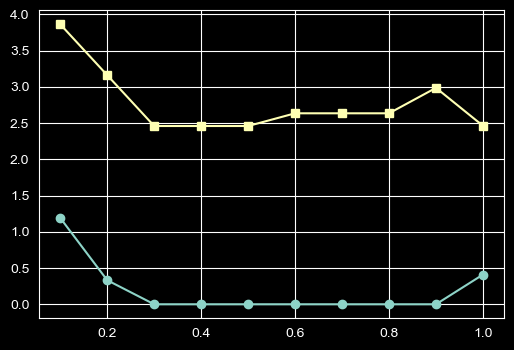

In [24]:
plt.figure(figsize=(6,4))
plt.plot(learning_rate, trn_err_, marker="o")
plt.plot(learning_rate, val_err_, marker="s")
plt.show()

In [29]:
# early stopping
number_of_steps = np.arange(1, 10, 1)
print(number_of_steps)
trn_err = np.zeros((len(number_of_steps), ))
val_err = np.zeros((len(number_of_steps), ))

[1 2 3 4 5 6 7 8 9]


In [26]:
trn_err.shape

(9,)

In [27]:
n_iters = np.zeros((len(number_of_steps), ))

In [30]:
for i , rounds in enumerate(number_of_steps):
    gbm = LGBMClassifier(boosting_type="gbdt", n_estimators=50, max_depth=1, early_stopping=int(rounds))
    gbm.fit(Xtr, ytr, eval_set=[(Xtst, ytst)], eval_metric="auc")
    trn_err[i] = 1 - accuracy_score(ytr, gbm.predict(Xtr))
    val_err[i] = 1 - accuracy_score(ytr, gbm.predict(Xtr))
    n_iters[i] = 1 - accuracy_score(ytr, gbm.predict(Xtr))

[LightGBM] [Warning] early_stopping_round is set=1, early_stopping=1 will be ignored. Current value: early_stopping_round=1
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4536
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Warning] early_stopping_round is set=1, early_stopping=1 will be ignored. Current value: early_stopping_round=1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 1 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\skle

[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000333 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4536
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Warning] early_stopping_round is set=9, early_stopping=9 will be ignored. Current value: early_stopping_round=9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 9 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\anaconda\envs\heima\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


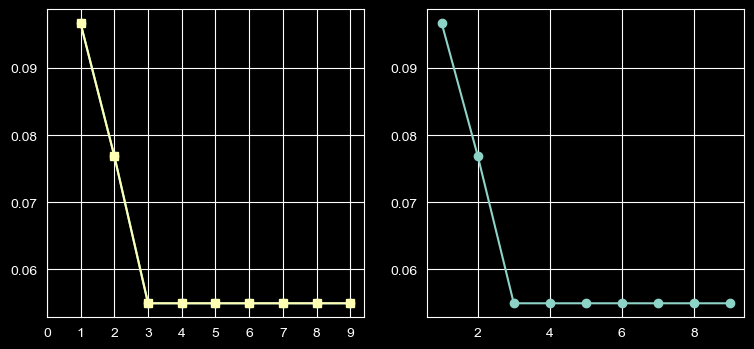

In [33]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
ax[0].plot(number_of_steps, trn_err, marker="o")
ax[0].plot(number_of_steps, val_err, marker="s")
ax[0].set_xticks(range(10))
ax[1].plot(number_of_steps, n_iters, marker="o")
plt.show()